# Import Necessery Libraries

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Better looking plots
sns.set_style("whitegrid")
%matplotlib inline

# Load the data

In [46]:
df = pd.read_csv("student_performance_dataset.csv")
df.head()

,Student_ID,Gender,Age,Study_Hours_Per_Day,Attendance_Rate(%),Previous_Score,Tutoring_Support,Parent_Education,Extracurricular,Sleep_Hours,Math_Score,Reading_Score,Writing_Score,Average_Score,Grade
0,STU0001,Male,16,2.7,77,76,No,PhD,No,5.8,50,50,53,51.0,D
1,STU0002,Female,17,5.9,56,93,No,High School,No,4.8,63,62,62,62.3,C
2,STU0003,Male,15,8.9,84,87,Yes,High School,Yes,7.7,88,85,96,89.7,A
3,STU0004,Male,15,7.6,77,78,No,Bachelor,Yes,5.8,79,85,85,83.0,A
4,STU0005,Male,15,8.3,63,67,Yes,High School,No,6.0,74,81,86,80.3,A


# Quick data overview

In [47]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing values:\n", df.isna().sum().sum())
print("\nGrade distribution:\n", df['Grade'].value_counts().sort_index())

Shape: (1000, 15)

Columns:
 ['Student_ID', 'Gender', 'Age', 'Study_Hours_Per_Day', 'Attendance_Rate(%)', 'Previous_Score', 'Tutoring_Support', 'Parent_Education', 'Extracurricular', 'Sleep_Hours', 'Math_Score', 'Reading_Score', 'Writing_Score', 'Average_Score', 'Grade']

Missing values:
 0

Grade distribution:
 Grade
A    146
B    199
C    249
D    213
F    193
Name: count, dtype: int64


# Define features and target

In [48]:
target = 'Average_Score'

features = [
    'Gender', 'Age', 'Study_Hours_Per_Day', 'Attendance_Rate(%)',
    'Previous_Score', 'Tutoring_Support', 'Parent_Education',
    'Extracurricular', 'Sleep_Hours'
]

X = df[features].copy()
y = df[target].copy()

print("Features used:", features)
print("Target:", target)

Features used: ['Gender', 'Age', 'Study_Hours_Per_Day', 'Attendance_Rate(%)', 'Previous_Score', 'Tutoring_Support', 'Parent_Education', 'Extracurricular', 'Sleep_Hours']
Target: Average_Score


# Split numerical & categorical columns

In [49]:
categorical_cols = ['Gender', 'Tutoring_Support', 'Parent_Education', 'Extracurricular']
numerical_cols   = ['Age', 'Study_Hours_Per_Day', 'Attendance_Rate(%)', 'Previous_Score', 'Sleep_Hours']

print("Categorical:", categorical_cols)
print("Numerical:  ", numerical_cols)

Categorical: ['Gender', 'Tutoring_Support', 'Parent_Education', 'Extracurricular']
Numerical:   ['Age', 'Study_Hours_Per_Day', 'Attendance_Rate(%)', 'Previous_Score', 'Sleep_Hours']


# Create preprocessing + model pipeline

In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

# rain / test split

In [51]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y, 
    test_size = 0.2,
    random_state = 42
)

# Fit the model

In [52]:
model.fit(x_train, y_train)

print("Training complete!")

print("Processed train shape:", x_train.shape)
print("Processed test shape:", x_test.shape)

Training complete!
Processed train shape: (800, 13)
Processed test shape: (200, 13)


# Predictions & evaluation metrics

In [53]:
y_pred = model.predict(x_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("──────────────────────────")
print(f"MAE:  {mae:6.3f} points")
print(f"RMSE: {rmse:6.3f} points")
print(f"R²:   {r2:6.3f}  ({r2*100:.1f}%)")

Linear Regression Results
──────────────────────────
MAE:   6.196 points
RMSE:  7.647 points
R²:    0.695  (69.5%)


# Show feature importance / coefficients

In [54]:
# Get feature names after encoding
feature_names = (
    numerical_cols +
    list(model.named_steps['preprocessor']
         .named_transformers_['cat']
         .get_feature_names_out(categorical_cols))
)

coefs = model.named_steps['regressor'].coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs
}).sort_values('coefficient', key=abs, ascending=False)

coef_df.style.format({'coefficient': '{:.3f}'})

,feature,coefficient
1,Study_Hours_Per_Day,10.938
2,Attendance_Rate(%),4.082
3,Previous_Score,3.691
5,Gender_1,1.313
4,Sleep_Hours,-0.622
10,Extracurricular_1,0.535
8,Parent_Education_2,0.478
7,Parent_Education_1,0.427
6,Tutoring_Support_1,0.297
9,Parent_Education_3,0.145


# Actual vs Predicted scatter plot

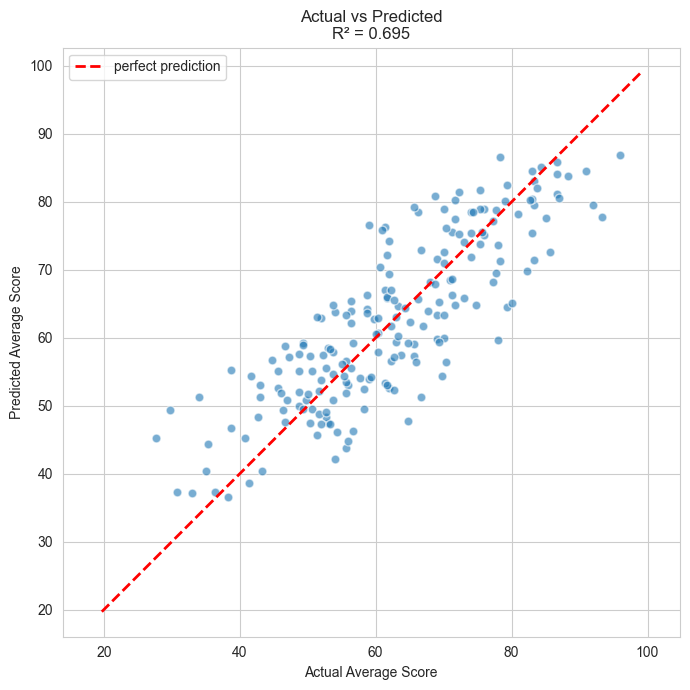

In [55]:
plt.figure(figsize=(7, 7))

plt.scatter(y_test, y_pred, alpha=0.6, s=40, edgecolor='white')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='perfect prediction')

plt.xlabel('Actual Average Score')
plt.ylabel('Predicted Average Score')
plt.title(f'Actual vs Predicted\nR² = {r2:.3f}')
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()

# Predict one new student average grade example

In [56]:
new_student = pd.DataFrame({
    'Gender':           ['Male'],
    'Age':              [16],
    'Study_Hours_Per_Day': [5.5],
    'Attendance_Rate(%)':  [88],
    'Previous_Score':   [82],
    'Tutoring_Support': ['Yes'],
    'Parent_Education': ['Bachelor'],
    'Extracurricular':  ['Yes'],
    'Sleep_Hours':      [7.5]
})

pred = model.predict(new_student)[0]

print(f"Predicted average score: {pred:.1f}")

Predicted average score: 68.2


C:\Users\MIR SHAHADUT HOSSAIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
